<a href="https://colab.research.google.com/github/Henibela/Neural-codes/blob/main/baseline_ber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

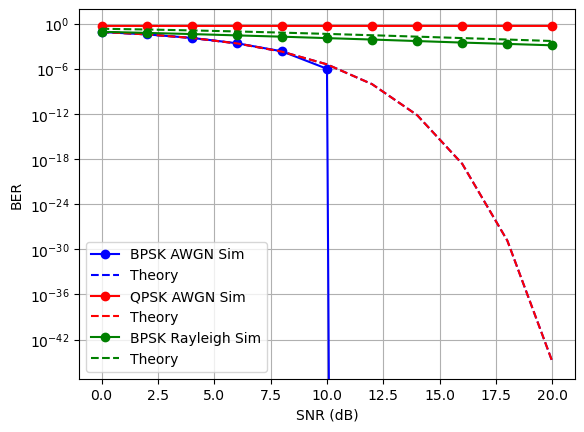

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Use vectorized erfc from SciPy if available; otherwise fall back to math.erfc
try:
    from scipy.special import erfc  # vectorized ufunc
except Exception:
    from math import erfc as _erfc
    erfc = np.vectorize(_erfc)

def ber_theory_bpsk(snr_db):
    return 0.5 * erfc(np.sqrt(10**(snr_db/10)))

def ber_theory_qpsk(snr_db):
    return ber_theory_bpsk(snr_db)

def ber_theory_rayleigh(snr_db):
    snr = 10**(snr_db/10)
    return 0.5 * (1 - np.sqrt(snr / (2 + snr)))

N = 1000000  # bits
snr_db = np.arange(0, 21, 2)

ber_bpsk_awgn = []
ber_qpsk_awgn = []
ber_bpsk_ray = []
for db in snr_db:
    snr = 10**(db/10)
    sigma = np.sqrt(1 / (2 * snr))  # BPSK

    bits = np.random.randint(0, 2, N)
    s_bpsk = 2*bits - 1
    s_qpsk = (2*bits[::2]-1) + 1j*(2*bits[1::2]-1)
    s_qpsk /= np.sqrt(2)  # Normalize

    noise = sigma * (np.random.randn(N) + 1j*np.random.randn(N))
    rx_bpsk = s_bpsk + noise.real
    rx_qpsk = s_qpsk + noise[:N//2]

    demod_bpsk = rx_bpsk > 0
    demod_qpsk_i = rx_qpsk.real > 0
    demod_qpsk_q = rx_qpsk.imag > 0
    demod_qpsk = np.concatenate((demod_qpsk_i, demod_qpsk_q)).astype(int)

    ber_bpsk_awgn.append(np.mean(bits != demod_bpsk))
    ber_qpsk_awgn.append(np.mean(bits[:N//2*2] != demod_qpsk))

    # Rayleigh BPSK
    h = (np.random.randn(N) + 1j*np.random.randn(N)) / np.sqrt(2)
    rx_ray = h * s_bpsk + noise.real  # Assume coherent detection (divide by h)
    demod_ray = np.real(rx_ray / h) > 0
    ber_bpsk_ray.append(np.mean(bits != demod_ray))

plt.semilogy(snr_db, ber_bpsk_awgn, 'b-o', label='BPSK AWGN Sim')
plt.semilogy(snr_db, ber_theory_bpsk(snr_db), 'b--', label='Theory')
plt.semilogy(snr_db, ber_qpsk_awgn, 'r-o', label='QPSK AWGN Sim')
plt.semilogy(snr_db, ber_theory_qpsk(snr_db), 'r--', label='Theory')
plt.semilogy(snr_db, ber_bpsk_ray, 'g-o', label='BPSK Rayleigh Sim')
plt.semilogy(snr_db, ber_theory_rayleigh(snr_db), 'g--', label='Theory')
plt.xlabel('SNR (dB)'); plt.ylabel('BER'); plt.grid(True); plt.legend()
plt.savefig('ber_validation.png')
plt.show()

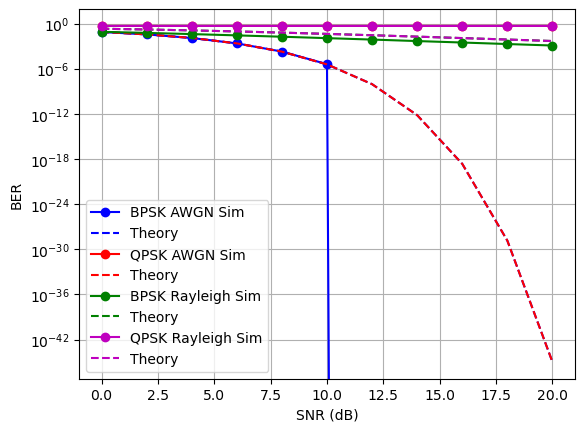

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

def ber_theory_bpsk_awgn(snr_db):
    return 0.5 * erfc(np.sqrt(10**(snr_db/10)))

def ber_theory_qpsk_awgn(snr_db):
    return ber_theory_bpsk_awgn(snr_db)

def ber_theory_bpsk_rayleigh(snr_db):
    snr = 10**(snr_db/10)
    return 0.5 * (1 - np.sqrt(snr / (2 + snr)))

def ber_theory_qpsk_rayleigh(snr_db):
    return ber_theory_bpsk_rayleigh(snr_db)  # same Eb/N0

N = 10000000  # 10^7 bits for lower BER
snr_db = np.arange(0, 21, 2)

ber_bpsk_awgn = []
ber_qpsk_awgn = []
ber_bpsk_ray = []
ber_qpsk_ray = []
for db in snr_db:
    snr = 10**(db/10)
    sigma = np.sqrt(1 / (2 * snr))

    bits = np.random.randint(0, 2, N)
    s_bpsk = 2*bits - 1
    s_qpsk = (2*bits[::2]-1) + 1j*(2*bits[1::2]-1)
    s_qpsk /= np.sqrt(2)

    noise = sigma * (np.random.randn(N) + 1j*np.random.randn(N))
    rx_bpsk = s_bpsk + noise.real
    rx_qpsk = s_qpsk + noise[:N//2]

    demod_bpsk = rx_bpsk > 0
    demod_qpsk_i = rx_qpsk.real > 0
    demod_qpsk_q = rx_qpsk.imag > 0
    demod_qpsk = np.concatenate((demod_qpsk_i, demod_qpsk_q)).astype(int)

    ber_bpsk_awgn.append(np.mean(bits != demod_bpsk))
    ber_qpsk_awgn.append(np.mean(bits[:N//2*2] != demod_qpsk))

    # Rayleigh BPSK
    h = (np.random.randn(N) + 1j*np.random.randn(N)) / np.sqrt(2)
    rx_ray_bpsk = h * s_bpsk + noise.real
    demod_ray_bpsk = np.real(rx_ray_bpsk / h) > 0
    ber_bpsk_ray.append(np.mean(bits != demod_ray_bpsk))

    # Rayleigh QPSK (coherent detection)
    h_qpsk = h[:N//2]  # per symbol
    rx_ray_qpsk = h_qpsk * s_qpsk + noise[:N//2]
    demod_ray_qpsk_i = np.real(rx_ray_qpsk / h_qpsk) > 0
    demod_ray_qpsk_q = np.imag(rx_ray_qpsk / h_qpsk) > 0
    demod_ray_qpsk = np.concatenate((demod_ray_qpsk_i, demod_ray_qpsk_q)).astype(int)
    ber_qpsk_ray.append(np.mean(bits[:N//2*2] != demod_ray_qpsk))

plt.semilogy(snr_db, ber_bpsk_awgn, 'b-o', label='BPSK AWGN Sim')
plt.semilogy(snr_db, ber_theory_bpsk_awgn(snr_db), 'b--', label='Theory')
plt.semilogy(snr_db, ber_qpsk_awgn, 'r-o', label='QPSK AWGN Sim')
plt.semilogy(snr_db, ber_theory_qpsk_awgn(snr_db), 'r--', label='Theory')
plt.semilogy(snr_db, ber_bpsk_ray, 'g-o', label='BPSK Rayleigh Sim')
plt.semilogy(snr_db, ber_theory_bpsk_rayleigh(snr_db), 'g--', label='Theory')
plt.semilogy(snr_db, ber_qpsk_ray, 'm-o', label='QPSK Rayleigh Sim')
plt.semilogy(snr_db, ber_theory_qpsk_rayleigh(snr_db), 'm--', label='Theory')
plt.xlabel('SNR (dB)'); plt.ylabel('BER'); plt.grid(True); plt.legend()
plt.savefig('ber_validation_extended.png')
plt.show()